In [4]:
# -----------------------------
# 1. Install / Import Libraries
# -----------------------------

!pip install -q torch torchvision scikit-learn pandas matplotlib seaborn pillow

import os
import glob
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import densenet169, DenseNet169_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

In [5]:
# -----------------------------
# 2. Mount Google Drive
# -----------------------------

from google.colab import drive
drive.mount('/content/drive')

# CHANGE THESE PATHS
DATASET_DIR = "/content/drive/MyDrive/MILK10k/MILK10k_Training_Input"
CSV_PATH = "/content/drive/MyDrive/MILK10k/MILK10k_Training_GroundTruth.csv"

OUTPUT_DIR = "/content/drive/MyDrive/SkinLesionProject/outputs"
WEIGHTS_DIR = "/content/drive/MyDrive/SkinLesionProject/weights"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(WEIGHTS_DIR, "best_densenet169_milk10k.pth")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# -----------------------------
# 3. Reproducibility
# -----------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [7]:
# -----------------------------
# 4. GPU Setup
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU Name: Tesla T4


In [10]:
# -----------------------------
# 5. Load CSV and Convert One-Hot Labels
# -----------------------------

DATASET_DIR = "/content/drive/MyDrive/SkinLesionDataset/MILK10k_Training_Input"
CSV_PATH = "/content/drive/MyDrive/SkinLesionDataset/MILK10k_Training_GroundTruth.csv"

OUTPUT_DIR = "/content/drive/MyDrive/SkinLesionProject/outputs"
WEIGHTS_DIR = "/content/drive/MyDrive/SkinLesionProject/weights"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(WEIGHTS_DIR, "best_densenet169_milk10k.pth")

df = pd.read_csv(CSV_PATH)

print("CSV loaded successfully")
print(df.head())
print(df.columns)

possible_id_cols = [
    "image",
    "image_id",
    "id",
    "lesion_id",
    "folder",
    "filename",
    "name",
    "Image",
    "Image_ID"
]

id_col = None

for col in df.columns:
    if col in possible_id_cols or col.lower() in [x.lower() for x in possible_id_cols]:
        id_col = col
        break

if id_col is None:
    id_col = df.columns[0]

print("Detected ID column:", id_col)

label_cols = [col for col in df.columns if col != id_col]

df["label"] = df[label_cols].values.argmax(axis=1)

class_names = label_cols
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)
print(df[[id_col, "label"]].head())

CSV loaded successfully
    lesion_id  AKIEC  BCC  BEN_OTH  BKL  DF  INF  MAL_OTH  MEL  NV  SCCKA  \
0  IL_0000652      0    1        0    0   0    0        0    0   0      0   
1  IL_0003176      0    1        0    0   0    0        0    0   0      0   
2  IL_0004688      0    1        0    0   0    0        0    0   0      0   
3  IL_0005081      0    0        0    0   0    0        0    0   0      1   
4  IL_0006177      0    1        0    0   0    0        0    0   0      0   

   VASC  
0     0  
1     0  
2     0  
3     0  
4     0  
Index(['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH',
       'MEL', 'NV', 'SCCKA', 'VASC'],
      dtype='object')
Detected ID column: lesion_id
Number of classes: 11
Classes: ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']
    lesion_id  label
0  IL_0000652      1
1  IL_0003176      1
2  IL_0004688      1
3  IL_0005081      9
4  IL_0006177      1


In [11]:
# -----------------------------
# 6. Dynamically Find Image Files
# -----------------------------

image_extensions = [
    "*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff",
    "*.JPG", "*.JPEG", "*.PNG", "*.BMP", "*.TIF", "*.TIFF"
]

def find_image_path(folder_id):
    """
    The MILK10k dataset stores images inside nested folders.

    Example:
    MILK10k_Training_Input/IL_3186878/image.png

    This function searches inside each folder and finds the actual image file.
    It does not assume the image is .jpg.
    """

    folder_id = str(folder_id).strip()

    folder_path = os.path.join(DATASET_DIR, folder_id)

    if not os.path.isdir(folder_path):
        return None

    image_paths = []

    for ext in image_extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

    if len(image_paths) == 0:
        return None

    return image_paths[0]


df["image_path"] = df[id_col].apply(find_image_path)

missing = df["image_path"].isna().sum()

print("Missing image paths:", missing)

if missing > 0:
    print("Examples of rows with missing images:")
    print(df[df["image_path"].isna()].head())

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Final usable dataset size:", len(df))
print(df[[id_col, "image_path", "label"]].head())

Missing image paths: 0
Final usable dataset size: 5240
    lesion_id                                         image_path  label
0  IL_0000652  /content/drive/MyDrive/SkinLesionDataset/MILK1...      1
1  IL_0003176  /content/drive/MyDrive/SkinLesionDataset/MILK1...      1
2  IL_0004688  /content/drive/MyDrive/SkinLesionDataset/MILK1...      1
3  IL_0005081  /content/drive/MyDrive/SkinLesionDataset/MILK1...      9
4  IL_0006177  /content/drive/MyDrive/SkinLesionDataset/MILK1...      1


In [12]:
# -----------------------------
# 7. Stratified Train / Validation / Test Split
# -----------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Train size: 3668
Validation size: 786
Test size: 786

Train class distribution:
label
0      212
1     1765
2       31
3      381
4       37
5       35
6        6
7      315
8      522
9      331
10      33
Name: count, dtype: int64

Validation class distribution:
label
0      46
1     379
2       6
3      82
4       7
5       7
6       2
7      67
8     112
9      71
10      7
Name: count, dtype: int64

Test class distribution:
label
0      45
1     378
2       7
3      81
4       8
5       8
6       1
7      68
8     112
9      71
10      7
Name: count, dtype: int64


In [13]:
# -----------------------------
# 8. Image Transformations
# -----------------------------

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
# -----------------------------
# 9. Custom PyTorch Dataset
# -----------------------------

class MILK10kDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label


train_dataset = MILK10kDataset(train_df, transform=train_transforms)
val_dataset = MILK10kDataset(val_df, transform=eval_transforms)
test_dataset = MILK10kDataset(test_df, transform=eval_transforms)

print("Datasets created successfully")
print("Train dataset length:", len(train_dataset))
print("Validation dataset length:", len(val_dataset))
print("Test dataset length:", len(test_dataset))

Datasets created successfully
Train dataset length: 3668
Validation dataset length: 786
Test dataset length: 786


In [15]:
# -----------------------------
# 10. DataLoaders
# -----------------------------

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("One batch image tensor shape:", images.shape)
print("One batch label tensor shape:", labels.shape)

One batch image tensor shape: torch.Size([32, 3, 224, 224])
One batch label tensor shape: torch.Size([32])


In [16]:
# -----------------------------
# 11. DenseNet169 Model
# -----------------------------

weights = DenseNet169_Weights.DEFAULT
model = densenet169(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

model = model.to(device)

print("DenseNet169 model created successfully")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 181MB/s]


DenseNet169 model created successfully
Sequential(
  (0): Linear(in_features=1664, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=11, bias=True)
)


In [17]:
# -----------------------------
# 12. Loss Function and Optimizer
# -----------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2
)

print("Loss function, optimizer, and scheduler are ready")

Loss function, optimizer, and scheduler are ready


In [18]:
# -----------------------------
# 13. Training and Validation Functions
# -----------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [19]:
# -----------------------------
# 14. Main Training Loop
# -----------------------------

EPOCHS = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved")

end_time = time.time()

print(f"\nTraining completed in {(end_time - start_time) / 60:.2f} minutes")
print("Best validation accuracy:", best_val_acc)

model.load_state_dict(best_model_wts)


Epoch 1/15
----------------------------------------
Train Loss: 1.4366 | Train Acc: 0.5480
Val Loss:   1.3199 | Val Acc:   0.5840
Best model saved

Epoch 2/15
----------------------------------------
Train Loss: 1.2751 | Train Acc: 0.5864
Val Loss:   1.2771 | Val Acc:   0.5954
Best model saved

Epoch 3/15
----------------------------------------
Train Loss: 1.2333 | Train Acc: 0.6006
Val Loss:   1.2204 | Val Acc:   0.6018
Best model saved

Epoch 4/15
----------------------------------------
Train Loss: 1.1837 | Train Acc: 0.6101
Val Loss:   1.2408 | Val Acc:   0.5891

Epoch 5/15
----------------------------------------
Train Loss: 1.1738 | Train Acc: 0.6224
Val Loss:   1.1875 | Val Acc:   0.6120
Best model saved

Epoch 6/15
----------------------------------------
Train Loss: 1.1596 | Train Acc: 0.6221
Val Loss:   1.1735 | Val Acc:   0.6107

Epoch 7/15
----------------------------------------
Train Loss: 1.1347 | Train Acc: 0.6240
Val Loss:   1.1735 | Val Acc:   0.6158
Best model save

<All keys matched successfully>

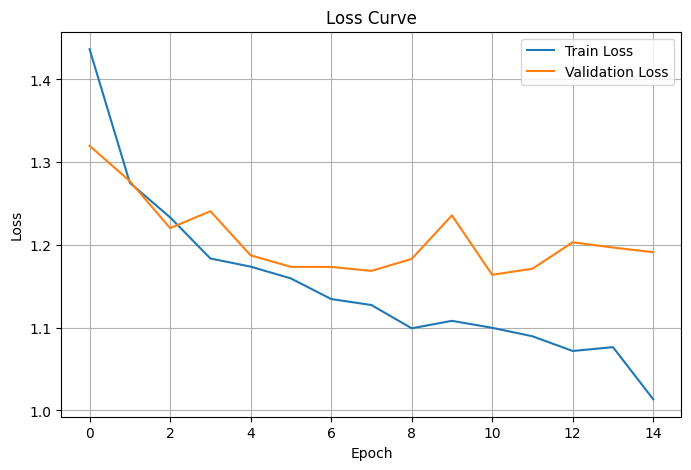

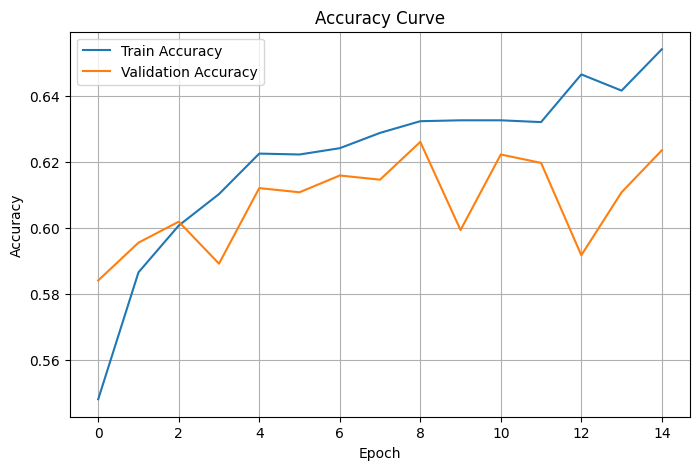

In [20]:
# -----------------------------
# 15. Plot Loss and Accuracy Curves
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_curve.png"), dpi=300)
plt.show()

In [21]:
# -----------------------------
# 16. Test Evaluation
# -----------------------------

def evaluate_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    softmax = nn.Softmax(dim=1)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = softmax(outputs)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)

test_accuracy = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Test Accuracy:", test_accuracy)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1-score:", f1_macro)
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1-score:", f1_weighted)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test Accuracy: 0.6132315521628499
Macro Precision: 0.2685308511408775
Macro Recall: 0.21567443712914577
Macro F1-score: 0.2115055307101871
Weighted Precision: 0.5472802953544772
Weighted Recall: 0.6132315521628499
Weighted F1-score: 0.5443053714711656

Classification Report:
              precision    recall  f1-score   support

       AKIEC       0.25      0.02      0.04        45
         BCC       0.66      0.91      0.77       378
     BEN_OTH       0.00      0.00      0.00         7
         BKL       0.24      0.12      0.16        81
          DF       0.00      0.00      0.00         8
         INF       0.00      0.00      0.00         8
     MAL_OTH       0.00      0.00      0.00         1
         MEL       0.63      0.18      0.28        68
          NV       0.56      0.83      0.67       112
       SCCKA       0.61      0.31      0.41        71
        VASC       0.00      0.00      0.00         7

    accuracy                           0.61       786
   macro avg       0

In [22]:
# -----------------------------
# 17. ROC-AUC Score
# -----------------------------

try:
    roc_auc_macro = roc_auc_score(
        y_true,
        y_probs,
        multi_class="ovr",
        average="macro"
    )

    roc_auc_weighted = roc_auc_score(
        y_true,
        y_probs,
        multi_class="ovr",
        average="weighted"
    )

    print("ROC-AUC Macro:", roc_auc_macro)
    print("ROC-AUC Weighted:", roc_auc_weighted)

except Exception as e:
    print("ROC-AUC could not be calculated:", e)

ROC-AUC Macro: 0.8274935775616604
ROC-AUC Weighted: 0.8399507507655607


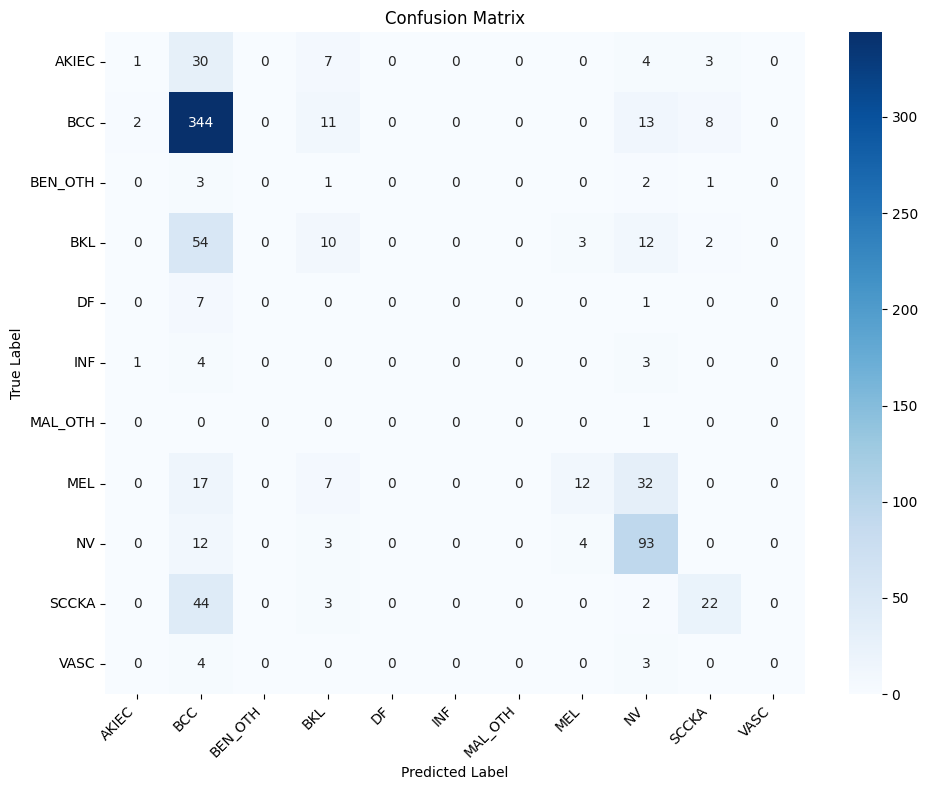

Confusion matrix saved to: /content/drive/MyDrive/SkinLesionProject/outputs/confusion_matrix.png


In [23]:
# -----------------------------
# 18. Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

confusion_matrix_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)

In [24]:
# -----------------------------
# 19. Save Metrics Report
# -----------------------------

report_path = os.path.join(OUTPUT_DIR, "metrics_report.txt")

with open(report_path, "w") as f:
    f.write("Skin Lesion Classification using DenseNet169\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Macro Precision: {precision_macro:.4f}\n")
    f.write(f"Macro Recall: {recall_macro:.4f}\n")
    f.write(f"Macro F1-score: {f1_macro:.4f}\n")
    f.write(f"Weighted Precision: {precision_weighted:.4f}\n")
    f.write(f"Weighted Recall: {recall_weighted:.4f}\n")
    f.write(f"Weighted F1-score: {f1_weighted:.4f}\n\n")

    try:
        f.write(f"ROC-AUC Macro: {roc_auc_macro:.4f}\n")
        f.write(f"ROC-AUC Weighted: {roc_auc_weighted:.4f}\n\n")
    except:
        pass

    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print("Metrics report saved to:", report_path)
print("Best model saved to:", BEST_MODEL_PATH)

Metrics report saved to: /content/drive/MyDrive/SkinLesionProject/outputs/metrics_report.txt
Best model saved to: /content/drive/MyDrive/SkinLesionProject/weights/best_densenet169_milk10k.pth
